# YOLO using CVAT

## ❗ Before you start, change runtime type to GPU!!! ❗
**Runtime > Change Runtime Type > GPU (any) > Save**

Change


## I. Labelling dataset preparation

1. **Set up environment**

In [4]:
!pip install git+https://github.com/WLi0777/LearnTracking.git
!pip install ultralytics
!pip install --upgrade torch torchvision torchaudio
import os

2. **Prepare folders and environment**

**Optional: mount your google drive.**

*You can proceed without doing so, but all progress will be stored in ephemeral memory that will be lost when Colab runtime is disconnected*

In [5]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

# setup working directory
os.makedirs('/content/drive/MyDrive/YOLO_butterflies', exist_ok=True)
working_path = '/content/drive/MyDrive/YOLO_butterflies'
os.chdir(working_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
from dataprep.video_extraction import extract_frames
from dataprep.setup_folders import create_folders_yolo
from google.colab import files
import shutil
import os

if 'working_path' not in locals():
  working_path = '/content/'
  os.chdir(working_path)

video_folder    = os.path.join(working_path,"original_video")
frames_folder   = os.path.join(working_path,"frames_for_labeling")
labeled_folder  = os.path.join(working_path,"yolo_folder")
total_frames    = os.path.join(working_path,"frames_for_labeling/total_video_frames")

create_folders_yolo(video_folder, frames_folder, labeled_folder, total_frames)

Created folders: /content/drive/MyDrive/YOLO_butterflies/original_video, /content/drive/MyDrive/YOLO_butterflies/frames_for_labeling, /content/drive/MyDrive/YOLO_butterflies/yolo_folder, /content/drive/MyDrive/YOLO_butterflies/frames_for_labeling/total_video_frames


3. **❗Upload the videos to /content/original_video**❗

(or if you mounted your Google drive: /content/drive/MyDrive/YOLO/original_video)

**For the purposes of this tutorial we will use this time lapse video of empbryonic cell mitosis from the Cell Image Library.**

*Download the .mp4 via this link: https://www.cellimagelibrary.org/download/web_mp4/15798*

In [15]:
# Get video files
video_files = sorted([f for f in os.listdir(video_folder) if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))])
if video_files:
    print("All Video Files:", video_files)
else:
    print("No video files found.")

All Video Files: ['Butterflies_C0270_Herato.MP4']


In [ ]:
# extract frames
extract_frames(
        input_path = video_folder,
        output_folder = frames_folder,
        frame_number = 40,  # percentage = 100 or frame_number = 10
        method = "kmeans"  # Choose "uniform" or "random" or "kmeans"
        )

shutil.make_archive(frames_folder, 'zip', frames_folder)
files.download(os.path.join(working_path,'frames_for_labeling.zip'))

All Video Files: ['Butterflies_Cam3_vid_19.avi']


## II. Labeling - CVAT


1. **Create a New Task**:
   - Task Name: `MitosisDetection`
   - Labels (Constructor): `Add Label`
   - Label Name: `MitosisEvent`
   - Type: `Rectangle`
   - Click `Continue` to save the setting

   **Upload Frames**:
   - Under `Select Files`, upload the frames
   - Click `Submit & Continue` to save
   

2. **Start Labeling**:
   - In the `Jobs` section, find the job to label and start the labeling process
   - Selecet 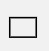, choose `By 2 points` & `Shape`

3. **Save Labeling**:
   - Click `Menu` and select `Export job dataset`
   - Export format: **`Ultralytics YOLO Detection 1.0`**
   - Save, download the file


4. **Upload Labeling**:
   - Upload .zip file to /content/yolo_folder
   (or if you mounted your Google drive: /content/drive/MyDrive/YOLO/yolo_folder)

## III. YOLO Training Dataset Preparation

In [17]:
from dataprep.yolo_prep import prepare_yolo_dataset, find_yaml_file
total_frames    = os.path.join(working_path,"frames_for_labeling/total_video_frames")
prepare_yolo_dataset(
        base_folder=labeled_folder,
        source_images_folder=total_frames,
        train_percentage=80
    )

yaml_file = find_yaml_file(labeled_folder)

Extracted job_3732613_annotations_2026_03_15_22_33_52_ultralytics yolo detection 1.0.zip to /content/drive/MyDrive/YOLO_butterflies/yolo_folder/job_3732613_annotations_2026_03_15_22_33_52_ultralytics yolo detection 1.0
Train and val split completed. Train: 32 frames, Val: 8 frames
Updated YAML file at: /content/drive/MyDrive/YOLO_butterflies/yolo_folder/job_3732613_annotations_2026_03_15_22_33_52_ultralytics yolo detection 1.0/data.yaml


## IV. YOLO Training

In [ ]:
from ultralytics import YOLO
import os
# Load a model
model = YOLO("yolo26s.pt")  # load a pretrained model (recommended for training)
# model = YOLO("/content/drive/MyDrive/YOLO/runs/detect/train6/weights/last.pt")  # load a pretrained model (recommended for training)

if yaml_file:
    # Train the model
    results = model.train(data=yaml_file, epochs=100, imgsz=640)
else:
    print("Can not find the yaml file")

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/YOLO_butterflies/yolo_folder/job_3732613_annotations_2026_03_15_22_33_52_ultralytics yolo detection 1.0/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train,

## V. View Model Output

Load the customised model and annotate the original video. See the results in the folder /content/original_video/Annotated_video  (or if you mounted your Google drive: /content/drive/MyDrive/YOLO/original_video/Annotated_video)

In [ ]:
import re
import glob
# Path to runs/detect/
detect_path           = os.path.join(working_path, 'runs/detect')
# Get all training run folders (train, train1, train2, ...)
train_folders         = [d for d in os.listdir(detect_path) if d.startswith('train') and os.path.isdir(os.path.join(detect_path, d))]
# Extract numbers and sort to find the highest
train_folders_sorted  = sorted(train_folders, key=lambda x: int(re.search(r'\d*$', x).group() or 0), reverse=True)
# Find the latest training run
latest_train_folder   = train_folders_sorted[0]
weights_path          = os.path.join(detect_path, latest_train_folder, 'weights')
# Find best.pt inside the latest training run
best_model_paths      = sorted(glob.glob(os.path.join(weights_path, "best.pt")), key=os.path.getmtime, reverse=True)
latest_model_path     = best_model_paths[0]

# Load the trained YOLO model
print(f"Loading model from: {latest_model_path}")
model   = YOLO(latest_model_path)

# Process each video
for video in video_files:
    video_path = os.path.join(video_folder, video)  # Full path of the video
    video_name = os.path.splitext(video)[0]  # Get filename without extension

    print(f"Processing: {video}")

    # Run YOLO track on the video
    results = model.track(
          source=video_path,
          save=True,
          project=os.path.join(video_folder, 'Annotated_video'),
          name=video_name,
          tracker="bytetrack.yaml",
          persist=True,
          conf=0.1,
          iou=0.7
      )

Loading model from: /content/drive/MyDrive/YOLO/runs/detect/train7/weights/best.pt
Processing: Butterflies_Cam3_vid_19.avi

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/945) /content/drive/MyDrive/YOLO/original_video/Butterflies_Cam3_vid_19.avi: 384x640 (no detections), 53.1ms
video 1/1 (frame 2/945) /content/drive/MyDrive/YOLO/original_video/Butterflies_Cam3_vid_19.avi: 384x640 (no detections), 9.2ms
video 1/1 (frame 3/945) /content/drive/MyDrive/YOLO/original_video/Butterflies_C

## VI. Clean the trajectories

First, let's plot the trajectories. The following section stores our results in a dataframe, then plots the raw trajectories

In [ ]:
import pandas as pd

rows = []

for frame_idx, r in enumerate(results):
    if r.boxes is None or len(r.boxes) == 0:
        continue
    if r.boxes.id is None:
        continue

    boxes = r.boxes.xyxy.cpu().numpy()
    ids = r.boxes.id.cpu().numpy().astype(int)
    confs = r.boxes.conf.cpu().numpy()

    for box, track_id, conf in zip(boxes, ids, confs):
        x1, y1, x2, y2 = box
        xc = 0.5 * (x1 + x2)
        yc = 0.5 * (y1 + y2)

        rows.append({
            "video": video_name,
            "frame": frame_idx,
            "track_id": track_id,
            "conf": float(conf),
            "x1": float(x1),
            "y1": float(y1),
            "x2": float(x2),
            "y2": float(y2),
            "xc": float(xc),
            "yc": float(yc),
            "w": float(x2 - x1),
            "h": float(y2 - y1),
        })

traj_df = pd.DataFrame(rows)
traj_df.head()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

for track_id, grp in traj_df.groupby("track_id"):
    grp = grp.sort_values("frame")
    plt.plot(grp["xc"], grp["yc"], marker='o', markersize=2, label=f"ID {track_id}")

plt.gca().invert_yaxis()
plt.xlabel("x position (px)")
plt.ylabel("y position (px)")
plt.title(f"Raw ByteTrack trajectories: {video_name}")
plt.legend()
plt.show()